In [1]:
# import libraries
import pandas as pd
import ee
import geemap

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
)

import matplotlib.pyplot as plt
import seaborn as sns

## Connect to Google Earth Engine (GEE)

In [2]:
# Authenticate GEE
ee.Authenticate()
ee.Initialize()

## Parameters

In [3]:
GLC_URBAN_CODE = 190          # "Impervious_surfaces" class in GLC_FCS30D legend
START_YEAR = 2015
END_YEAR = 2022   

## Visualization Parameters

In [4]:
# Center coordinates to show map
fct_center =  (9.056266, 7.498522)

In [5]:
# Map to visualise land cover layers
lc_map = geemap.Map(center = fct_center, zoom=8)
lc_map.add_basemap("SATELLITE")


# Maps to visualise thematic layers
thematic_map_1 = geemap.Map(center = fct_center, zoom=8)
thematic_map_1.add_basemap("SATELLITE")

thematic_map_2 = geemap.Map(center = fct_center, zoom=8)
thematic_map_2.add_basemap("SATELLITE")

In [6]:
# Boundary visualization params 
vis_params_fao_1 = {
  "fillColor": 'b5ffb4',
  "color": '00909F',
  "width": 1.0,
}

vis_params_aoi = {"fillcolor": "", "color": "red"}

# Sentinel-2 Visualization parameters 
vis_params_s2_rgb = {"min" : 0, "max" :0.3, "bands": ["B4", "B3", "B2"]}
vis_params_s2_fcc = {"min" : 0, "max" :0.3, "bands": ["B8", "B4", "B3"]}


# Spectral indices visualization parameters
# NDVI
vis_params_ndvi = {
    "min": -0.2,
    "max": 0.8,
    "palette": [
        "#a50026",  
        "#d73027",
        "#f46d43",
        "#fdae61",
        "#fee08b",
        "#d9ef8b",
        "#a6d96a",
        "#66bd63",
        "#1a9850",
        "#006837",  
    ],
}

# NDBI
vis_params_ndbi = {
    "min": -0.5,
    "max": 0.5,
    "palette": [
        "#f7f7f7",  
        "#fddbc7",
        "#f4a582",
        "#d6604d",
        "#b2182b",  
    ],
}

# NDWI
vis_params_ndwi = {
    "min": -0.5,
    "max": 0.5,
    "palette": [
        "#f7fbff",  
        "#deebf7",
        "#9ecae1",
        "#4292c6",
        "#2171b5",
        "#08306b",  
    ],
}


# Visualisation parameters for road layers
vis_params_roads_vector = {
                        "color": "red",
                        "width": 1.5,
                    }

vis_params_roads_raster = {
                        "min": 0,
                        "max": 1,
                        "palette": ["black", "white"],
                    }


vis_params_dist_road = {
    "min": 0,
    "max": 21730, #meters
    "palette": [
        "#d73027",  
        "#f46d43",
        "#fdae61",
        "#fee08b",
        "#d9ef8b",
        "#a6d96a",
        "#1a9850",  
    ],
}

# Visualisation parameters for water layers
vis_params_water = {
    "min": 0,
    "max": 1,
    "palette": ["white", "blue"], 
}

# Distance to water
vis_params_dist_water = {
    "min": 0,
    "max": 38497,  
    "palette": [
        "#f7fbff",  
        "#deebf7",
        "#9ecae1",
        "#4292c6",
        "#2171b5",
        "#08306b",  
    ],
}


# Nighttime lights visualisation parameters
vis_params_ntl = {
    "min": 0,
    "max": 20,  
    "palette": [
        "#000000",  
        "#2c0b00",
        "#6e1c00",
        "#a83800",
        "#d9720a",
        "#f7b733",
        "#ffe98a",  
    ],
}


# Visualization parameters for GPWv411 population DENSITY layer
vis_params_gpw = {
  "min": 0.0,
  "max": 10000.0,
  "palette": ["ffffe7", "FFc869", "ffac1d", "e17735", "f2552c", "9f0c21"]
}

## Helper Functions

In [7]:
# Function to export Image to Drive
def export_image_to_drive(image: ee.Image, description: str, folder: str, extent: ee.Geometry, scale: int, crs: str = 'EPSG:4326'):
    """
    Starts a Google Earth Engine batch task to export a raster image to Google Drive.

    Args:
        image (ee.Image): The Earth Engine image to be exported.
        description (str): A human-readable name for the task and the output file prefix.
        folder (str): The name of the Google Drive folder where the file will be saved.
        extent (ee.Geometry): The regional boundary (AOI) to clip the export to.
        scale (int): The resolution in meters per pixel (e.g., 10 for Sentinel-2).
        crs (str): The coordinate reference system.

    Returns:
        None: The function initiates an asynchronous background task.
    """
    # Convert all bands to Float32 (or Float64)
    image = image.toFloat()

    task = ee.batch.Export.image.toDrive(
        image=image,
        description=description,
        folder=folder,
        fileNamePrefix=description,
        region=extent,
        scale=scale,
        crs=crs,
        maxPixels=1e13
    )
    task.start()
    return task
    print(f"Started export: {description}")

## Boundary Data

In [8]:
# Boundary data from FAO GAUL
# Data source: https://developers.google.com/earth-engine/datasets/catalog/FAO_GAUL_SIMPLIFIED_500m_2015_level0
fao_gaul_l0 = ee.FeatureCollection('FAO/GAUL_SIMPLIFIED_500m/2015/level0') # Countries boundaries
fao_gaul_l1 = ee.FeatureCollection('FAO/GAUL_SIMPLIFIED_500m/2015/level1') # States boundaries
fao_gaul_l2 = ee.FeatureCollection('FAO/GAUL_SIMPLIFIED_500m/2015/level2') # LGAs boundaries

styleParams = {
  "fillColor": 'b5ffb4',
  "color": '00909F',
  "width": 1.0,
}

#dataset = dataset.style(styleParams)

# Create map to visualize the FAO GAUL boundary data
boundary_map = geemap.Map(center=(7.0, 8.0), zoom=10)

boundary_map.addLayer(fao_gaul_l0, {}, 'Country Boundaries')
boundary_map.addLayer(fao_gaul_l1, {}, 'State Boundaries')
boundary_map.addLayer(fao_gaul_l2, {}, 'LGA Boundaries')
boundary_map

Map(center=[7.0, 8.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

In [9]:
# Select just a single feature
print(fao_gaul_l0.limit(1).getInfo()["columns"])
nga_l0 = fao_gaul_l0.filter(ee.Filter.eq("ADM0_NAME", "Nigeria"))
nga_l1 = fao_gaul_l1.filter(ee.Filter.eq("ADM0_NAME", "Nigeria"))
fct_l0 = nga_l1.filter(ee.Filter.eq("ADM1_NAME", "Abuja")) # FCT extent
print(fct_l0.getInfo())

# Get geometry from FCT boundary (FeatureCollection)
aoi = fct_l0.geometry()
aoi_bbox = aoi.bounds()

# Creat map to visualize FCT boundary data
aoi_map = geemap.Map(center=fct_center, zoom=10)
aoi_map.addLayer(fct_l0, vis_params_aoi, 'FCT Boundary')
aoi_map

{'ADM0_CODE': 'Integer', 'ADM0_NAME': 'String', 'DISP_AREA': 'String', 'EXP0_YEAR': 'Integer', 'STATUS': 'String', 'STR0_YEAR': 'Integer', 'Shape_Area': 'Float', 'Shape_Leng': 'Float', 'system:index': 'String'}
{'type': 'FeatureCollection', 'columns': {'ADM0_CODE': 'Integer', 'ADM0_NAME': 'String', 'ADM1_CODE': 'Integer', 'ADM1_NAME': 'String', 'DISP_AREA': 'String', 'EXP1_YEAR': 'Integer', 'STATUS': 'String', 'STR1_YEAR': 'Integer', 'Shape_Area': 'Float', 'Shape_Leng': 'Float', 'system:index': 'String'}, 'version': 1701682755394127, 'id': 'FAO/GAUL_SIMPLIFIED_500m/2015/level1', 'properties': {'system:asset_size': 80042928}, 'features': [{'type': 'Feature', 'geometry': {'type': 'Polygon', 'coordinates': [[[6.746250262158974, 8.996497434811962], [6.748495969531178, 8.992005993451773], [6.748495969531178, 8.989760187648406], [6.748495969531178, 8.985268685352079], [6.748495969531178, 8.983022905093227], [6.748495969531178, 8.98077718923787], [6.750741754879445, 8.971794157254672], [6.757

Map(center=[9.056266, 7.498522], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

## Explore Image operations

In [10]:
# Image Collection
# Data Source: 
s2_img_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') # All Sentinel-2 collection
    .filterDate('2022-01-01', '2022-01-31') # Limit/filter to January 2022
    .filterBounds(fct_l0.geometry()) # Limit/filter to Abuja
    # Pre-filter to get less cloudy granules.
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

# Apply scaling factor
def apply_scale(image):
    scaled_image = image.multiply(0.0001).copyProperties(image, ['system:time_start'])
    return  scaled_image

s2_img_col = s2_img_col.map(apply_scale)

# Collection Properties
print(f"Number of images in S2 collection: {s2_img_col.size().getInfo()}\n")


# First image in collection
first_s2_img = s2_img_col.first()
print(f"First image in S2 collection: {first_s2_img.getInfo()}\n")

# Bands in S2 image
print(first_s2_img.bandNames().getInfo())

# Select just a few bands
red_band_s2 = first_s2_img.select(["B4", "B3", "B2"])
print(f"Red Band: {red_band_s2.bandNames().getInfo()}")


# Visualize S2 image
s2_map = geemap.Map(center=fct_center, zoom=8)
s2_map.addLayer(fct_l0, vis_params_aoi, 'FCT Boundary')
s2_map.addLayer(first_s2_img.clip(aoi), vis_params_s2_rgb, "First S2 Img")
s2_map

Number of images in S2 collection: 20

First image in S2 collection: {'type': 'Image', 'bands': [{'id': 'B1', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 6.5535000000000005}, 'dimensions': [1830, 1830], 'crs': 'EPSG:32632', 'crs_transform': [60, 0, 199980, 0, -60, 1000020]}, {'id': 'B2', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 6.5535000000000005}, 'dimensions': [10980, 10980], 'crs': 'EPSG:32632', 'crs_transform': [10, 0, 199980, 0, -10, 1000020]}, {'id': 'B3', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 6.5535000000000005}, 'dimensions': [10980, 10980], 'crs': 'EPSG:32632', 'crs_transform': [10, 0, 199980, 0, -10, 1000020]}, {'id': 'B4', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 6.5535000000000005}, 'dimensions': [10980, 10980], 'crs': 'EPSG:32632', 'crs_transform': [10, 0, 199980, 0, -10, 1000020]}, {'id': 'B5', 'data_type': {'type': 'PixelType', 'precisio

Map(center=[9.056266, 7.498522], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [11]:
# Mosaic the entire S2 collection & clip to FCT extent [Spatial Mosaic]
s2_mosaic = s2_img_col.mosaic()
s2_mosaic_clipped = s2_mosaic.clip(aoi)
print(f"Mosaiced S2 Collection {s2_mosaic.getInfo()}")

s2_map.addLayer(s2_mosaic_clipped, vis_params_s2_rgb, "S2 Mosaiced - Spatial")
s2_map

Mosaiced S2 Collection {'type': 'Image', 'bands': [{'id': 'B1', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 6.5535000000000005}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'B2', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 6.5535000000000005}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'B3', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 6.5535000000000005}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'B4', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 6.5535000000000005}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'B5', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 6.5535000000000005}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'B6', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 6.5535000000000005}, 'crs'

Map(center=[9.056266, 7.498522], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [12]:
# Compute median composite the entire S2 collection & clip to FCT extent [Temporal Composite]
s2_median = s2_img_col.median().clip(aoi)
print(f"Median of S2 collection: {s2_median.getInfo()}")

# Compute spectral indices
ndvi = s2_median.normalizedDifference(["B8", "B4"]).rename("ndvi")
ndwi = s2_median.normalizedDifference(["B3", "B8"]).rename("ndwi")

s2_map.addLayer(s2_median, vis_params_s2_fcc, "S2 Median Comp")
s2_map.addLayer(ndvi, vis_params_ndvi, "S2 NDVI")
s2_map.addLayer(ndwi, vis_params_ndwi, "S2 NDWI")
s2_map

Median of S2 collection: {'type': 'Image', 'bands': [{'id': 'B1', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 6.5535000000000005}, 'dimensions': [3, 3], 'origin': [6, 7], 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'B2', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 6.5535000000000005}, 'dimensions': [3, 3], 'origin': [6, 7], 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'B3', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 6.5535000000000005}, 'dimensions': [3, 3], 'origin': [6, 7], 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'B4', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 6.5535000000000005}, 'dimensions': [3, 3], 'origin': [6, 7], 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'B5', 'data_type': {'type': 'PixelType', 'precision': 'double', 'min': 0, 'max': 6.5535000000000005}, 'dimension

Map(center=[9.056266, 7.498522], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

## . Land Cover / Existing Urban Layer (GLC_FCS30D: 2012–2022)

The raw GLC_FCS30D asset is stored as tiled, multi-band images (one band per
year). We mosaic the tiles, rename the bands to actual years, and convert the
multi-band image into a proper year-indexed `ImageCollection`.

In the GLC_FCS30D legend, class code **190 = Impervious surfaces** (built-up /
urban). We use this to derive a binary urban mask for every year.

In [51]:
ee.List.sequence(2000, 2022)

In [13]:
# GLC_FCS30D Global Land Cover
# Data source : https://gee-community-catalog.org/projects/glc_fcs/?h=glc+fcs30d
# Reference   : https://gee-community-catalog.org/tutorials/examples/glc_fcs30d_lulc/
glc_annual = ee.ImageCollection("projects/sat-io/open-datasets/GLC-FCS30D/annual")
glc_mosaic = glc_annual.mosaic()

# Mosaic tiled images and rename bands b1, b2, ... to 2000, 2001, ...
# Each image in annual land cover data has 23 bands, one for each year from 2000-2022 (23 years)
glc_years = ee.List.sequence(2000, 2022).map(lambda y: ee.Number(y).format("%04d"))
glc_mosaic_renamed = glc_mosaic.rename(glc_years)

print("GLC_FCS30D bands Original:", glc_mosaic.bandNames().slice(0, 5).getInfo(), "...")
print("GLC_FCS30D bands renamed:", glc_mosaic_renamed.bandNames().slice(0, 5).getInfo(), "...")


GLC_FCS30D bands Original: ['b1', 'b2', 'b3', 'b4', 'b5'] ...
GLC_FCS30D bands renamed: ['2000', '2001', '2002', '2003', '2004'] ...


In [14]:
# Classification scheme
# (35 landcover class and 1 fill value)
lc_class_values =  [
  10, 11, 12, 20, 51, 52, 61, 62, 71, 72, 81, 82, 91, 92, 120, 121, 122, 
  130, 140, 150, 152, 153, 181, 182, 183, 184, 185, 186, 187, 190, 200, 
  201, 202, 210, 220, 0
]

# Land cover class names
glc_class_names = [
    "Rainfed_cropland", "Herbaceous_cover_cropland", "Tree_or_shrub_cover_cropland",
    "Irrigated_cropland", "Open_evergreen_broadleaved_forest", "Closed_evergreen_broadleaved_forest",
    "Open_deciduous_broadleaved_forest", "Closed_deciduous_broadleaved_forest",
    "Open_evergreen_needle_leaved_forest", "Closed_evergreen_needle_leaved_forest",
    "Open_deciduous_needle_leaved_forest", "Closed_deciduous_needle_leaved_forest",
    "Open_mixed_leaf_forest", "Closed_mixed_leaf_forest", "Shrubland",
    "Evergreen_shrubland", "Deciduous_shrubland", "Grassland", "Lichens_and_mosses",
    "Sparse_vegetation", "Sparse_shrubland", "Sparse_herbaceous", "Swamp", "Marsh",
    "Flooded_flat", "Saline", "Mangrove", "Salt_marsh", "Tidal_flat",
    "Impervious_surfaces", "Bare_areas", "Consolidated_bare_areas",
    "Unconsolidated_bare_areas", "Water_body", "Permanent_ice_and_snow", "Filled_value",
]

glc_class_colours = [
    "#ffff64", "#ffff64", "#ffff00", "#aaf0f0", "#4c7300",
    "#006400", "#a8c800", "#00a000", "#005000", "#003c00",
    "#286400", "#285000", "#a0b432", "#788200", "#966400",
    "#964b00", "#966400", "#ffb432", "#ffdcd2", "#ffebaf",
    "#ffd278", "#ffebaf", "#00a884", "#73ffdf", "#9ebb3b",
    "#828282", "#f57ab6", "#66cdab", "#444f89", "#c31400",
    "#fff5d7", "#dcdcdc", "#fff5d7", "#0046c8", "#ffffff", "#ffffff",
]

In [15]:
# Visualise land cover for FCT/Abuja
lc_map.addLayer(glc_mosaic_renamed.select("2015").clip(aoi), {"palette": glc_class_colours}, "Land cover - 2015")
lc_map.addLayer(glc_mosaic_renamed.select("2022").clip(aoi), {"palette": glc_class_colours}, "Land cover - 2022")
lc_map

Map(center=[9.056266, 7.498522], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [16]:
print(START_YEAR)
print(END_YEAR)

2015
2022


In [17]:
# Extract only Urban class from land cover 
def get_glc_urban_mask(year):
    '''Return a binary urban (1) / non-urban (0) image for a given year
    from the GLC_FCS30D dataset, clipped to the AOI.'''
    band_name = str(year)
    year_image = glc_mosaic_renamed.select([band_name])
    urban_mask = year_image.eq(GLC_URBAN_CODE).rename("urban")
    return urban_mask.clip(aoi).set({"year": year, "source": "GLC_FCS30D"})

# 
urban_by_year = {
    year: get_glc_urban_mask(year) for year in range(START_YEAR, END_YEAR + 1)
}
all_years = sorted(urban_by_year.keys())
print("Urban time series (GLC_FCS30D only) covers:", all_years)


Urban time series (GLC_FCS30D only) covers: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]


In [18]:
urban_vis = {"min": 0, "max": 1, "palette": ["00000000", "d7301f"]}

Map = geemap.Map()
Map.centerObject(aoi, 10)
lc_map.addLayer(fct_l0.style(color="black", fillColor="00000000"), {}, "FCT Boundary")

for year in [2015, 2018, 2022]:
    lc_map.addLayer(urban_by_year[year], urban_vis, f"Urban {year}")
lc_map


Map(center=[9.056266, 7.498522], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

## Annual Urban Area Change

In [19]:
def compute_urban_area_km2(urban_image, region=aoi, scale=30):
    '''Return total urban area in km^2 for a binary urban image.'''
    area_image = urban_image.multiply(ee.Image.pixelArea())
    stats = area_image.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=region,
        scale=scale,
        maxPixels=1e10,
    )
    area_m2 = ee.Number(stats.get("urban"))
    return area_m2.divide(1e6)  # convert m^2 -> km^2

urban_area_records = []
for year in all_years:
    area_km2 = compute_urban_area_km2(urban_by_year[year], scale=30).getInfo()
    urban_area_records.append({"year": year, "urban_area_km2": area_km2})
    print(f"{year}: {area_km2:.2f} km^2")

# To data frame
urban_area_df = pd.DataFrame(urban_area_records)
urban_area_df


2015: 435.00 km^2
2016: 455.22 km^2
2017: 467.52 km^2
2018: 471.19 km^2
2019: 477.16 km^2
2020: 476.84 km^2
2021: 478.24 km^2
2022: 471.26 km^2


,year,urban_area_km2
0,2015,435.001712
1,2016,455.222306
2,2017,467.516108
3,2018,471.194764
4,2019,477.158173
5,2020,476.843028
6,2021,478.243532
7,2022,471.264215


In [20]:
# Annual expansion rate (km^2/year and %/year)
urban_area_df["expansion_km2"] = urban_area_df["urban_area_km2"].diff()
urban_area_df["expansion_pct"] = urban_area_df["urban_area_km2"].pct_change() * 100
urban_area_df

,year,urban_area_km2,expansion_km2,expansion_pct
0,2015,435.001712,NaN,NaN
1,2016,455.222306,20.220595,4.648394
2,2017,467.516108,12.293801,2.700615
3,2018,471.194764,3.678657,0.786851
4,2019,477.158173,5.963408,1.265593
5,2020,476.843028,-0.315145,-0.066046
6,2021,478.243532,1.400504,0.293703
7,2022,471.264215,-6.979317,-1.459365


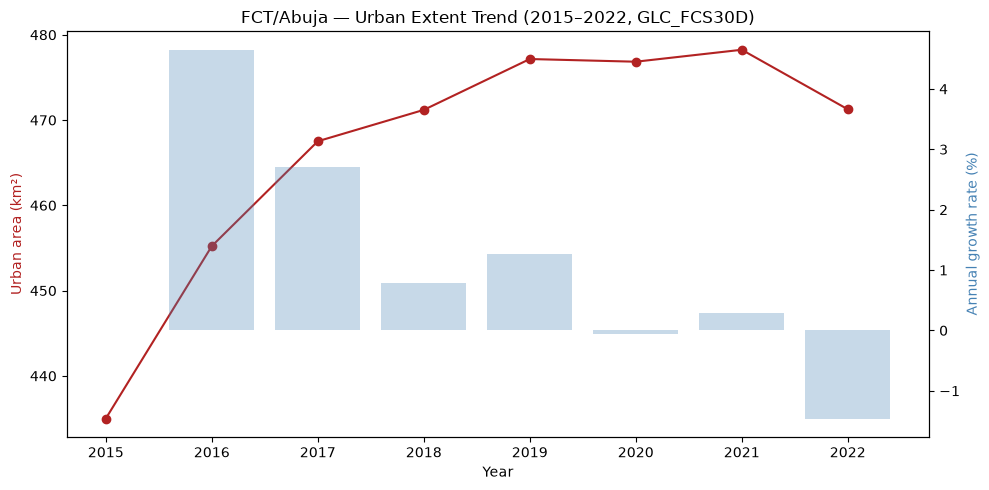

In [21]:

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(urban_area_df["year"], urban_area_df["urban_area_km2"], marker="o", color="firebrick")
ax1.set_xlabel("Year")
ax1.set_ylabel("Urban area (km²)", color="firebrick")
ax1.set_title("FCT/Abuja — Urban Extent Trend (2015–2022, GLC_FCS30D)")

ax2 = ax1.twinx()
ax2.bar(urban_area_df["year"], urban_area_df["expansion_pct"], alpha=0.3, color="steelblue")
ax2.set_ylabel("Annual growth rate (%)", color="steelblue")

plt.tight_layout()
plt.savefig("urban_growth_trend.png", dpi=200)
plt.show()


## Drivers of Urban Growth / Predictors (Thematic Layers)

Note that the driver of urban growth has different temporal resolution. Where possible, we used date close to 2022. 2022 is the later year in the land cover/urban change data.

In [22]:
CHECK

NameError: name 'CHECK' is not defined

**Elevation/DEM**

In [23]:
# Download elevation and compute slope
# Data source: https://developers.google.com/earth-engine/datasets/catalog/USGS_SRTMGL1_003
dem = ee.Image('USGS/SRTMGL1_003')
print(f"Bands in the DEM {dem.bandNames().getInfo()}")


elevation = dem.select('elevation')
slope = ee.Terrain.slope(elevation)

thematic_map_1.addLayer(dem.clip(aoi), {'min': 0, 'max': 500, "palette": ["Red", "Green", "Yellow"]}, "DEM")
thematic_map_1.addLayer(slope.clip(aoi), {'min': 0, 'max': 10, "palette": ["Red", "Green", "Yellow"]}, "Slope")
thematic_map_1

Bands in the DEM ['elevation']


Map(center=[9.056266, 7.498522], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

**Distance to Road**

In [24]:
# Distance to roads
# Data source: https://gee-community-catalog.org/projects/grip/
roads_africa = ee.FeatureCollection("projects/sat-io/open-datasets/GRIP4/Africa")

# Roads that intersect with study extent
roads_aoi = roads_africa.filterBounds(aoi_bbox)

# Convert road from vector to raster & compute eucledian distance 
roads_raster = ee.Image().float().paint(roads_aoi, 1).clip(aoi)
distance_to_roads = (
    roads_raster.fastDistanceTransform(256)
    .sqrt()
    .multiply(ee.Image.pixelArea().sqrt())  # convert pixel distance to meters
    .rename("dist_to_roads")
    .clip(aoi)
)

# Maximum distance in 'distance_to_roads' layer
print(distance_to_roads.reduceRegion(ee.Reducer.max(), aoi, 1000, maxPixels=1e9).getInfo())

thematic_map_1.addLayer(roads_raster, vis_params_roads_raster, "Road Raster")
thematic_map_1.addLayer(distance_to_roads.select("dist_to_roads"), vis_params_dist_road, "Distance to Road")
thematic_map_1.addLayer(roads_aoi, vis_params_roads_vector, "Road Vector")
thematic_map_1

{'dist_to_roads': 21729.478200706984}


Map(center=[9.056266, 7.498522], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

**Distance to Permanent Water**

In [25]:
# Permanent water (JRC Global Surface Water)
# Data Source: https://developers.google.com/earth-engine/datasets/catalog/JRC_GSW1_4_GlobalSurfaceWater
gsw = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").clip(aoi)
permanent_water = gsw.select("occurrence").gte(50)  # >=50% of the time = water

# compute eucledian distance 
distance_to_water = (
    permanent_water.Not()
    .fastDistanceTransform(256)
    .sqrt()
    .multiply(ee.Image.pixelArea().sqrt())
    .rename("dist_to_water")
    .clip(aoi)
)

# 
print(distance_to_water.reduceRegion(ee.Reducer.max(), aoi, 1000, maxPixels=1e9).getInfo())

thematic_map_1.addLayer(permanent_water, vis_params_water, "Permanent Water")
thematic_map_1.addLayer(distance_to_water.select("dist_to_water"), vis_params_dist_water, "Distance to Water")
thematic_map_1

{'dist_to_water': 38497.39218440647}


Map(bottom=31412.0, center=[9.056266, 7.498522], controls=(WidgetControl(options=['position', 'transparent_bg'…

**Nighttime Lights**

In [26]:
date = ee.Date("2015-01-01")
date_plus_1year = date.advance(-1, "year")

print(date.format("YYYY-MM-dd").getInfo())
print(date_plus_1year.format("YYYY-MM-dd").getInfo())

2015-01-01
2014-01-01


In [27]:
# Nighttime lights (VIIRS DNB, annual composite)
# Data Source: https://developers.google.com/earth-engine/datasets/catalog/NOAA_VIIRS_DNB_MONTHLY_V1_VCMSLCFG
def get_nighttime_lights(year, study_extent):
    '''Annual mean VIIRS radiance composite.'''
    start = ee.Date.fromYMD(year, 1, 1) # "2015", "january", "1"
    end = start.advance(1, "year")
    composite = (
        ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG")
        .filterDate(start, end)
        .select("avg_rad")
        .mean()
        .rename("ntl")
        .clip(study_extent)
    )
    return composite


# Apply function 
ntl_2015 = get_nighttime_lights(2015, aoi)
ntl_2020 = get_nighttime_lights(2020, aoi)
ntl_2022 = get_nighttime_lights(2022, aoi)


thematic_map_2.addLayer(ntl_2015, vis_params_ntl, "NTL - 2015")
thematic_map_2.addLayer(ntl_2020, vis_params_ntl, "NTL - 2020")
thematic_map_2.addLayer(ntl_2022, vis_params_ntl, "NTL - 2022")
thematic_map_2

Map(center=[9.056266, 7.498522], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

**Population Density**

In [28]:
# Population density (CIESIN GPWv4.11) 
# Data source: https://developers.google.com/earth-engine/datasets/catalog/CIESIN_GPWv411_GPW_Population_Density
# Closest available year to analysis baseline (2015 / 2020 / 2022).
gpw = ee.ImageCollection("CIESIN/GPWv411/GPW_Population_Density")

def get_population_density(year, extent):
    '''Return the GPWv4.11 population density image closest to the given year.'''
    available_years = [2000, 2005, 2010, 2015, 2020]
    closest_year = min(available_years, key=lambda y: abs(y - year))
    image = (
        gpw.filter(ee.Filter.calendarRange(closest_year, closest_year, "year"))
        .first()
        .select("population_density")
        .rename("pop_density")
        .clip(extent)
    )
    return image

# Apply function
pop_density_2015 = get_population_density(2015, aoi)
pop_density_2020 = get_population_density(2020, aoi)

thematic_map_2.addLayer(pop_density_2015, vis_params_gpw, "Population Density - 2015")
thematic_map_2.addLayer(pop_density_2020, vis_params_gpw, "Population Density - 2020")
thematic_map_2

Map(center=[9.056266, 7.498522], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

**Building Density**

**Spectral Indices**

In [29]:
# Spectral indices from Landsat (annual cloud-masked median composite) 
# Data Source: https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC08_C02_T1_L2
# Data Source: https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC09_C02_T1_L2


def mask_landsat_clouds(image):
    qa = image.select("QA_PIXEL")
    cloud_bit, shadow_bit = 1 << 3, 1 << 4
    mask = qa.bitwiseAnd(cloud_bit).eq(0).And(qa.bitwiseAnd(shadow_bit).eq(0))
    return image.updateMask(mask)

def get_spectral_indices(year):
    '''NDVI, NDBI, NDWI annual median composite from Landsat 8/9 SR.'''
    start = ee.Date.fromYMD(year, 1, 1)
    end = start.advance(1, "year")

    l8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterBounds(aoi).filterDate(start, end)
    l9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2").filterBounds(aoi).filterDate(start, end)
    landsat = l8.merge(l9).map(mask_landsat_clouds)

    # Apply scale factors
    def apply_scale_factors(image):
        optical = image.select("SR_B.").multiply(0.0000275).add(-0.2)
        return image.addBands(optical, None, True)

    landsat = landsat.map(apply_scale_factors)
    composite = landsat.median().clip(aoi)

    ndvi = composite.normalizedDifference(["SR_B5", "SR_B4"]).rename("ndvi")
    ndbi = composite.normalizedDifference(["SR_B6", "SR_B5"]).rename("ndbi")
    ndwi = composite.normalizedDifference(["SR_B3", "SR_B5"]).rename("ndwi")

    return ee.Image.cat([ndvi, ndbi, ndwi])

indices = get_spectral_indices(END_YEAR)


thematic_map_2.addLayer(indices.select("ndvi"), vis_params_ndvi, "NDVI")
thematic_map_2.addLayer(indices.select("ndbi"), vis_params_ndbi, "NDBI")
thematic_map_2.addLayer(indices.select("ndwi"), vis_params_ndwi, "NDWI")

thematic_map_2

Map(center=[9.056266, 7.498522], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

## . Combine Thematic Layers

In [53]:
# Combine/stack layers
# 2022 predictor stack 
predictor_stack = (
    elevation
    .addBands(slope)
    .addBands(distance_to_roads)
    .addBands(distance_to_water)
    .addBands(pop_density_2020)
    .addBands(ntl_2022)
    .addBands(indices)
)

print("Predictor bands:", predictor_stack.bandNames().getInfo())

Predictor bands: ['elevation', 'slope', 'dist_to_roads', 'dist_to_water', 'pop_density', 'ntl', 'ndvi', 'ndbi', 'ndwi']


In [31]:
# Resample stacked layers/images
predictor_stack_resampled = (predictor_stack.resample("bilinear")
                             .reproject(crs=predictor_stack.projection(), 
                                        scale=30))

In [54]:
END_YEAR

2022

In [55]:
urban_by_year.keys()

dict_keys([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])

In [32]:
# Fetch Urban layers. Each pixel here is either 0 (non-urban) or 1 (urban)
urban_2015 = urban_by_year[2015]
urban_2022 = urban_by_year[END_YEAR]

# Four Possible transitions
#   0 = Non-urban(2015) - Non-urban(2022)
#   1 = Non-urban(2015) - Urban(2022)
#   2 = Urban(2015)     - Non-urban(2022)
#   3 = Urban(2015)     - Urban(2022)


# Encode all 4 transition combinations in a single raster
transition_15_22 = urban_2015.multiply(2).add(urban_2022).rename("transition")


# Check unique pixel values
transition_hist = transition_15_22.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=aoi,
    scale=10,
    maxPixels=1e13
)

unique_transition_values = ee.Dictionary(transition_hist.get('transition')).keys().getInfo()
print(unique_transition_values)


['0', '1', '2', '3']


In [ ]:
# Keep two transitions: codes 0 and 1
non_urban_2015 = urban_2015.eq(0)

# The transition code (0 or 1) is already the label
change_label = transition_15_22.updateMask(non_urban_2015).rename("label")

print("Transition codes kept: 0 = stable non-urban, 1 = new urban (2015 - 2022)")

Transition codes kept: 0 = stable non-urban, 1 = new urban (2015 - 2022)


In [34]:
# Area of 4 transition classes
transition_area = ee.Image.pixelArea().addBands(transition_15_22).reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName="transition"),
    geometry=aoi,
    scale=30,
    maxPixels=1e10,
)

transition_groups = ee.List(transition_area.get("groups")).getInfo()
transition_names = {
    0: "Non-urban - Non-urban",
    1: "Non-urban - Urban (growth)",
    2: "Urban - Non-urban (loss)",
    3: "Urban - Urban (stable)",
}
for group in transition_groups:
    code_val = int(group["transition"])
    area_km2 = group["sum"] / 1e6
    print(f"{transition_names[code_val]:32s}: {area_km2:9.2f} km^2")


Non-urban - Non-urban           :   6857.92 km^2
Non-urban - Urban (growth)      :     62.15 km^2
Urban - Non-urban (loss)        :     25.89 km^2
Urban - Urban (stable)          :    409.12 km^2


In [35]:
# Final training image: predictor stack + land cover transition layer
training_image = (predictor_stack
                  .addBands(change_label)
                  .updateMask(non_urban_2015))

print(training_image.bandNames().getInfo())

['elevation', 'slope', 'dist_to_roads', 'dist_to_water', 'pop_density', 'ntl', 'ndvi', 'ndbi', 'ndwi', 'label']


In [36]:
CHECK

NameError: name 'CHECK' is not defined

## ML Modelling

In [37]:
# Maps to visualise ML results
ml_map = geemap.Map(center = fct_center, zoom=8)
ml_map.add_basemap("SATELLITE")

In [38]:
# Stratified random sample
NUM_POINTS_PER_CLASS = 1500

samples = training_image.stratifiedSample(
    numPoints=NUM_POINTS_PER_CLASS,
    classBand="label",
    region=aoi,
    scale=30,
    seed=42,
    geometries=True,
)

print("Total training samples:", samples.size().getInfo())
print("Class distribution:", samples.aggregate_histogram("label").getInfo())

Total training samples: 3000
Class distribution: {'0': 1500, '1': 1500}


In [39]:
# To pandas DataFrame from FC
def fc_to_df(fc):
    features = fc.getInfo()["features"]
    rows = [f["properties"] for f in features]
    return pd.DataFrame(rows)


samples_df = fc_to_df(samples)
samples_df = samples_df.dropna()
print(samples_df.shape)
display(samples_df.head())

(3000, 10)


,dist_to_roads,dist_to_water,elevation,label,ndbi,ndvi,ndwi,ntl,pop_density,slope
0,601.916412,1.065409e+04,498,0,0.080023,0.352740,-0.444916,0.375833,1692.968628,17.387035
1,2902.677835,1.138222e+04,234,0,0.152330,0.276026,-0.403343,0.254167,202.088928,3.954367
2,3264.435187,1.378096e+06,314,0,0.001915,0.432961,-0.485666,0.299167,196.609756,3.858516
3,15995.831307,7.710478e+02,164,0,0.096091,0.327781,-0.419013,0.244167,206.050842,1.877167
4,3845.315661,1.472730e+04,364,0,-0.046315,0.521811,-0.504621,0.292500,196.609741,2.780288


In [40]:
# Split samples into train/test. 75% training and 25% testing
samples_split = samples.randomColumn("random", seed=42)
train_samples = samples_split.filter(ee.Filter.lt("random", 0.75))
test_samples = samples_split.filter(ee.Filter.gte("random", 0.75))

print("Train samples:", train_samples.size().getInfo())
print("Test samples :", test_samples.size().getInfo())

Train samples: 2219
Test samples : 781


In [41]:
# Visualize the training and testing samples
training_style = {"color": "blue", "pointSize": 3}
testing_style = {"color": "red", "pointSize": 3}

training_layer = train_samples.style(**training_style)
testing_layer = test_samples.style(**testing_style)

ml_map.addLayer(fct_l0.style(color="black", fillColor="00000000"), {}, "FCT Boundary")
ml_map.addLayer(training_layer, {}, "Training Samples")
ml_map.addLayer(testing_layer, {}, "Testing Samples")

ml_map

Map(center=[9.056266, 7.498522], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [42]:
CHECK

NameError: name 'CHECK' is not defined

## Random Forest (Earth Engine) 

In [59]:
training_image.bandNames().getInfo()[:-1]

['elevation',
 'slope',
 'dist_to_roads',
 'dist_to_water',
 'pop_density',
 'ntl',
 'ndvi',
 'ndbi',
 'ndwi']

In [58]:
#print(training_image.bandNames().getInfo()[:-1])
feature_cols = training_image.bandNames().getInfo()[:-1]

In [44]:
# Initialize & Train Random Forest model
ee_classifier = ee.Classifier.smileRandomForest(
    numberOfTrees=500,
    minLeafPopulation=5,
    seed=42,
).setOutputMode("PROBABILITY")

ee_classifier_eval = ee_classifier.train(
    features=train_samples,
    classProperty="label",
    inputProperties=feature_cols,
)

print("Random forest trained on the train split.")


Random forest trained on the train split.


In [45]:
# Classify the held-out test portion
test_classified = test_samples.classify(ee_classifier_eval, outputName="suitability")
test_df = fc_to_df(test_classified).dropna()

y_true = test_df["label"].astype(int)
y_prob = test_df["suitability"]
y_pred = (y_prob >= 0.5).astype(int)

print("Held-out test-split results:")
print("Accuracy:", accuracy_score(y_true, y_pred))
print("ROC-AUC :", roc_auc_score(y_true, y_prob))
print()
print(classification_report(y_true, y_pred))

Held-out test-split results:
Accuracy: 0.9039692701664532
ROC-AUC : 0.9585951334688791

              precision    recall  f1-score   support

           0       0.89      0.92      0.90       386
           1       0.92      0.89      0.90       395

    accuracy                           0.90       781
   macro avg       0.90      0.90      0.90       781
weighted avg       0.90      0.90      0.90       781



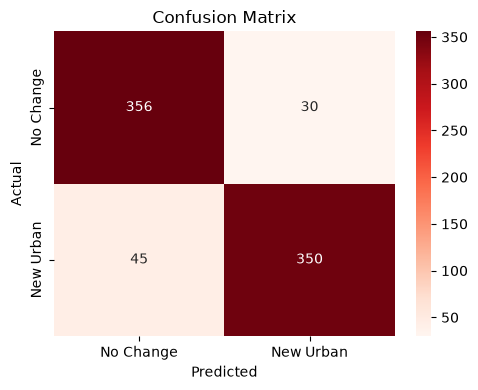

In [46]:
# Confusion matrix 
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["No Change", "New Urban"],
            yticklabels=["No Change", "New Urban"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200)
plt.show()

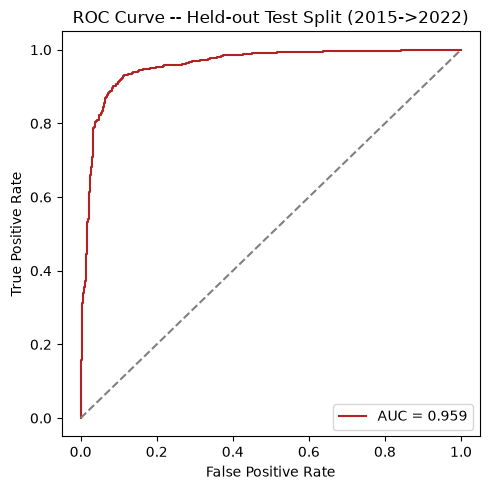

In [47]:
# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color="firebrick", label=f"AUC = {roc_auc_score(y_true, y_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve -- Held-out Test Split (2015->2022)")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=200)
plt.show()

In [48]:
# Retrain on the FULL sample set for the production model
ee_classifier_trained = ee_classifier.train(
    features=samples,
    classProperty="label",
    inputProperties=feature_cols,
)

print("Final random forest retrained on the full 2015 2022 sample set.")

Final random forest retrained on the full 2015 2022 sample set.


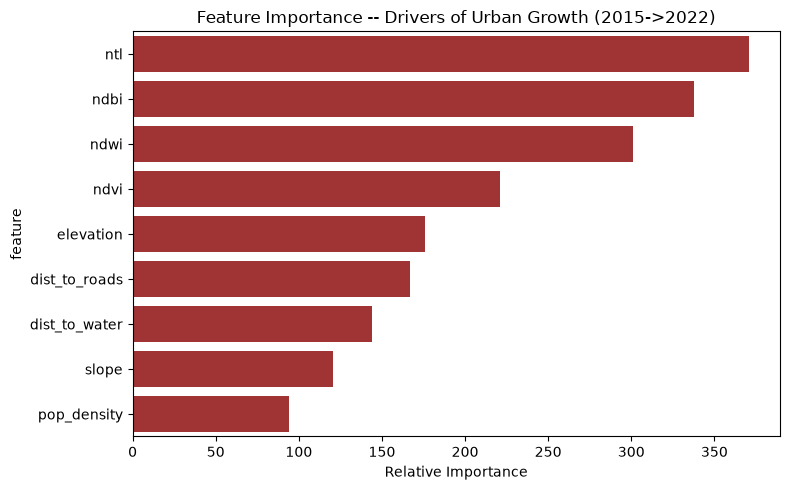

,feature,importance
6,ntl,370.922363
3,ndbi,337.570704
5,ndwi,301.081841
4,ndvi,221.174382
2,elevation,175.614955
0,dist_to_roads,167.015188
1,dist_to_water,144.140367
8,slope,120.539841
7,pop_density,93.910330


In [49]:
# Feature importance
importance_dict = ee_classifier_trained.explain().getInfo()["importance"]

importance_df = pd.DataFrame(
    list(importance_dict.items()), columns=["feature", "importance"]
).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="importance", y="feature", color="firebrick")
plt.title("Feature Importance -- Drivers of Urban Growth (2015->2022)")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=200)
plt.show()

importance_df

In [50]:
CHECK

NameError: name 'CHECK' is not defined

## Suitability Map (Apply trained model to every pixel)

In [ ]:
growth_suitability = predictor_stack.select(feature_cols).classify(
    ee_classifier_trained
).rename("suitability")




In [ ]:
suitability_map = geemap.Map(center=fct_center, zoom=10)


suitability_vis = {"min": 0, "max": 1, "palette": ["ffffcc", "fd8d3c", "800026"]}


suitability_map.addLayer(fct_l0.style(color="black", fillColor="00000000"), {}, "FCT Boundary")
suitability_map.addLayer(growth_suitability, suitability_vis, "Urban Growth Suitability")
suitability_map.add_colorbar(suitability_vis, label="Probability of becoming urban")
suitability_map

Map(center=[8.861296340730576, 7.141621582083702], controls=(WidgetControl(options=['position', 'transparent_b…

## Predict Urban Growth

In [ ]:
non_urban_2022 = urban_2022.eq(0)

In [ ]:

#
coeffs = np.polyfit(urban_area_df["year"], urban_area_df["urban_area_km2"], deg=1)
trend_slope, trend_intercept = coeffs

TARGET_YEAR = 2030
BASELINE_YEAR = END_YEAR  # 2022
projected_area_km2 = trend_slope * TARGET_YEAR + trend_intercept
current_area_km2 = urban_area_df.loc[urban_area_df["year"] == BASELINE_YEAR, "urban_area_km2"].values[0]
additional_area_km2 = max(projected_area_km2 - current_area_km2, 0)

print(f"Linear trend: {trend_slope:.2f} km^2/year")
print(f"Projected urban area by {TARGET_YEAR}: {projected_area_km2:.2f} km^2")
print(f"Additional area to allocate (from {BASELINE_YEAR} baseline): {additional_area_km2:.2f} km^2")


Linear trend: 4.80 km^2/year
Projected urban area by 2030: 521.71 km^2
Additional area to allocate (from 2022 baseline): 50.45 km^2


In [ ]:
print("current_area_km2:", current_area_km2)
print("projected_area_km2:", projected_area_km2)
print("additional_area_km2:", additional_area_km2)
print("trend_slope (km^2/year):", trend_slope)

current_area_km2: 471.2642145271141
projected_area_km2: 521.7127405307692
additional_area_km2: 50.448526003655104
trend_slope (km^2/year): 4.796283554180994


In [ ]:
# Suitability threshold 
candidate_suitability = growth_suitability.updateMask(non_urban_2022)

# First get total number of non-urban pixels in entire AOI.
non_urban_pixel_count = ee.Number(
    candidate_suitability.reduceRegion(
        reducer=ee.Reducer.count(),
        geometry=aoi,
        scale=30,
        maxPixels=1e10,
    ).get("suitability")
).getInfo()

print(f"Total non-urban pixels in AOI: {non_urban_pixel_count:,}")

In [ ]:
# Sample the suitability distribution's SHAPE only (not its count).
# Few thousand random points to estimate.
suitability_sample = candidate_suitability.sample(
    region=aoi, scale=30, numPixels=4000, seed=1
)
suitability_values = np.array(
    fc_to_df(suitability_sample)["suitability"].dropna()
)

In [ ]:
# Fraction of the true total is needed, and look up
# the matching percentile in the sampled distribution.
pixel_area_km2 = 30 * 30 / 1e6
n_pixels_needed = int(additional_area_km2 / pixel_area_km2)
n_pixels_needed = min(n_pixels_needed, non_urban_pixel_count)  # TRUE total, not the sample size

fraction_needed = n_pixels_needed / non_urban_pixel_count
percentile_cutoff = 100 * (1 - fraction_needed)
suitability_threshold = np.percentile(suitability_values, percentile_cutoff)

print(f"Pixels needed: {n_pixels_needed:,} of {non_urban_pixel_count:,} total non-urban pixels ({fraction_needed * 100:.3f}%)")
print(f"Suitability threshold for {TARGET_YEAR} allocation: {suitability_threshold:.3f}")

Pixels needed: 56,053 of 7,790,816 total non-urban pixels (0.719%)
Suitability threshold for 2030 allocation: 0.955


In [ ]:
CHECK